# Global Sales Analysis Project

## 1. Introduction


### 1.1. Project Goal

The main goal of this project is to perform data cleaning, analysis, and visualization of global sales data in order to uncover meaningful business insights.

The analysis focuses on understanding company performance across different product categories, countries, regions, and sales channels (online and offline).  
Special attention is given to shipping time analysis and its relationship with profitability.


### 1.2. Business Context and Analytical Questions
The company operates on a global market and sells products through both physical stores and online channels.  
Management is interested in understanding:

- overall business performance and key metrics;
- which product categories generate the highest revenue and profit;
- how sales performance differs across countries and regions;
- the impact of sales channels (online vs offline) on revenue and profitability;
- how long shipping takes in different regions and product categories;
- whether shipping time affects profitability;
- sales dynamics over time and potential seasonality patterns.

Answers to these questions can help the business optimize logistics, pricing strategy, product focus, and geographic expansion.


### 1.3. Dataset Structure and Analysis Approach
The dataset consists of three tables:

- `events.csv` — transactional sales data over several years;
- `products.csv` — product categories and product identifiers;
- `countries.csv` — country and region information.

The analysis approach includes the following steps:

1. Data overview and understanding of table structures and relationships;
2. Data cleaning: handling missing values, incorrect data types, duplicates, and anomalies;
3. Data preparation and merging tables into a single analytical dataset;
4. Exploratory data analysis and visualization of key metrics;
5. Time-based and shipping-related analysis;
6. Interpretation of results from a business perspective.

## 2. Environment Setup


In [ ]:
# 2.1 disk connection
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2.2 imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


In [ ]:
# basic viz settings
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")


In [ ]:
# 2.3 Project paths
PROJECT_PATH = Path("/content/drive/MyDrive/python_projects/global_retail_sales")
DATA_PATH = PROJECT_PATH / "data"
NOTEBOOKS_PATH = PROJECT_PATH / "notebooks"


In [ ]:
# sanity checks
print("PROJECT_PATH exists:", PROJECT_PATH.exists())
print("DATA_PATH exists:", DATA_PATH.exists())
print("NOTEBOOKS_PATH exists:", NOTEBOOKS_PATH.exists())


PROJECT_PATH exists: True
DATA_PATH exists: True
NOTEBOOKS_PATH exists: True


In [ ]:
# 2.4 Перевірка, що файли на місці

required_files = ["events.csv", "products.csv", "countries.csv"]

missing = [f for f in required_files if not (DATA_PATH / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing files in DATA_PATH: {missing}")

sorted([p.name for p in DATA_PATH.iterdir()])


['countries.csv', 'events.csv', 'products.csv']

In [ ]:
# 2.5 Load data
events = pd.read_csv(DATA_PATH / "events.csv")
products = pd.read_csv(DATA_PATH / "products.csv")
countries = pd.read_csv(DATA_PATH / "countries.csv")


In [ ]:
# 2.6 Quick preview
display(events.head())
display(products.head())
display(countries.head())


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


## 3. Data Overview
### 3.1 `events.csv` — initial exploration

In [ ]:
# 3.1.1 Shape, columns, types
print("events shape:", events.shape)
events.columns


events shape: (1330, 10)


Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code',
       'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost'],
      dtype='object')

In [ ]:
events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
# 3.1.2 Basic preview

display(events.head(3))
display(events.tail(3))


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33
1329,999879729,3/31/2012,5/6/2012,M,ALB,7940,Offline,5486.0,668.27,502.54


In [ ]:
# 3.1.3 Missing values
(events.isna().mean().sort_values(ascending=False) * 100).round(2)

,0
Country Code,6.17
Units Sold,0.15
Order Date,0.00
Order ID,0.00
Order Priority,0.00
Ship Date,0.00
Product ID,0.00
Sales Channel,0.00
Unit Price,0.00
Unit Cost,0.00


In [ ]:
# 3.1.4 Duplicate rows

events.duplicated().sum()

np.int64(0)

In [ ]:
# 3.1.5 Quick numeric sanity check

events.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Order ID,1330.0,5.412048e+08,2.573882e+08,1.006406e+08,3.190004e+08,5.387164e+08,7.544628e+08,9.998797e+08
Product ID,1330.0,5.788096e+03,2.820729e+03,1.270000e+03,3.127000e+03,5.988000e+03,8.681000e+03,8.969000e+03
Units Sold,1328.0,4.952202e+03,2.905199e+03,2.000000e+00,2.356750e+03,4.962000e+03,7.459500e+03,9.999000e+03
Unit Price,1330.0,2.648935e+02,2.173235e+02,9.330000e+00,8.173000e+01,1.540600e+02,4.372000e+02,6.682700e+02
Unit Cost,1330.0,1.872468e+02,1.761589e+02,6.920000e+00,3.584000e+01,9.744000e+01,2.633300e+02,5.249600e+02


### 3.1.6 Column description (events.csv)

The `events.csv` table contains transactional sales data and represents individual customer orders.

**Columns description:**

- **Order ID** — unique identifier of a customer order.
- **Order Date** — date when the order was placed.
- **Ship Date** — date when the order was shipped to the customer.
- **Order Priority** — priority level assigned to the order (e.g. Low, Medium, High, Critical).
- **Country Code** — ISO-like code representing the country where the order was placed.
- **Product ID** — unique identifier of the product sold.
- **Sales Channel** — channel through which the sale was made (Online or Offline).
- **Units Sold** — number of product units sold in the order.
- **Unit Price** — selling price per single unit of the product.
- **Unit Cost** — cost per single unit of the product.

**Key relationships:**
- `Product ID` is used to link `events.csv` with `products.csv`.
- `Country Code` is used to link `events.csv` with `countries.csv`.


### Initial observations

- The dataset does not contain fully duplicated rows.
- Date-related columns are stored as strings and will require conversion to datetime format.
- Missing values are present mainly in the `Country Code` column, which may affect geographic analysis.
- Numeric columns related to pricing and quantity do not show obvious anomalies at this stage.


### 3.2 `products.csv` — initial exploration



In [ ]:
# 3.2.1 Shape, columns, types

print("products shape:", products.shape)
products.columns

products shape: (12, 2)


Index(['id', 'item_type'], dtype='object')

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
# 3.2.2 Basic preview

display(products.head(3))
display(products.tail(3))

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes


,id,item_type
9,8293,Cosmetics
10,8969,Snacks
11,3127,Personal Care


In [ ]:
# 3.2.3 Missing values
(products.isna().mean().sort_values(ascending=False) * 100).round(2)

,0
id,0.0
item_type,0.0


In [ ]:
# 3.2.4 Duplicate rows

products.duplicated().sum()

np.int64(0)

### 3.2.5 Column description  (products.csv)

The `products.csv` table is a reference dataset that contains information about product categories.

**Columns description:**

- **id** — unique identifier of the product, used as a primary key.
- **item_type** — product category name.

**Key relationships:**
- The `id` column is used to link `products.csv` with `events.csv` via the `Product ID` field.


### Initial observations

- The table contains a small number of records and represents a product reference dictionary.
- No missing values or duplicated rows were detected.
- Product categories are well-defined and suitable for aggregation and comparative analysis.
- This table will be used to enrich transactional data with product category information.


## 3.3 `countries.csv` — initial exploration


In [ ]:
# 3.3.1 Shape, columns, types
print("countries shape:", countries.shape)
countries.columns


countries shape: (249, 5)


Index(['name', 'alpha-2', 'alpha-3', 'region', 'sub-region'], dtype='object')

In [ ]:
countries.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
# 3.3.2 Basic preview

display(countries.head(3))
display(countries.tail(3))

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe


,name,alpha-2,alpha-3,region,sub-region
246,Yemen,YE,YEM,Asia,Western Asia
247,Zambia,ZM,ZMB,Africa,Sub-Saharan Africa
248,Zimbabwe,ZW,ZWE,Africa,Sub-Saharan Africa


In [ ]:
# 3.3.3 Missing values

(countries.isna().mean().sort_values(ascending=False) * 100).round(2)


,0
alpha-2,0.4
sub-region,0.4
region,0.4
name,0.0
alpha-3,0.0


In [ ]:
# 3.3.4 Duplicate rows

countries.duplicated().sum()

np.int64(0)

In [ ]:
# 3.3.5 Duplicate check by key columns

countries["alpha-3"].duplicated().sum()

np.int64(0)

### 3.3.6 Column description (countries.csv)

The `countries.csv` table is a geographic reference dataset that provides country and regional information.

**Columns description:**

- **name** — full country name.
- **alpha-2** — two-letter country code.
- **alpha-3** — three-letter country code, used as a unique country identifier.
- **region** — high-level geographic region.
- **sub-region** — more detailed geographic sub-region.

**Key relationships:**
- The `alpha-3` column is used to link `countries.csv` with `events.csv` via the country code field.


### Initial observations

- The table contains geographic reference data for countries and regions.
- The `alpha-3` column can be considered a unique country identifier.
- A small percentage of missing values is present in `alpha-2`, `region`, and `sub-region`.
- Missing regional information may affect region-level analysis and will be addressed during the data cleaning stage.


## 4. Data Cleaning
### 4.1 Minimal cleaning for table merging



#### 4.1.1 events.csv — preparation for merge

**Step 1. Standardize column names**

In [ ]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
    )
    return df

events = clean_columns(events)
products = clean_columns(products)
countries = clean_columns(countries)


print(events.columns)
print(products.columns)
print(countries.columns)

Index(['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code',
       'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost'],
      dtype='object')
Index(['id', 'item_type'], dtype='object')
Index(['name', 'alpha_2', 'alpha_3', 'region', 'sub_region'], dtype='object')


**Step 2. Convert date columns**

In [ ]:
# Date conversion

events['order_date'] = pd.to_datetime(events['order_date'])
events['ship_date'] = pd.to_datetime(events['ship_date'])


In [ ]:
# Logic check
(events['ship_date'] < events['order_date']).sum()

np.int64(0)

In [ ]:
events.dtypes

,0
order_id,int64
order_date,datetime64[ns]
ship_date,datetime64[ns]
order_priority,object
country_code,object
product_id,int64
sales_channel,object
units_sold,float64
unit_price,float64
unit_cost,float64


Dates were converted to datetime format to enable time-based analysis and calculation of shipping intervals.  
A logical consistency check confirmed that no orders were shipped before their order date.


In [ ]:
# Step 2.1 Fix numeric dtypes (coerce + контроль помилок)

numeric_cols = ["units_sold", "unit_price", "unit_cost"]

for col in numeric_cols:
    if col in events.columns:
        before_na = events[col].isna().sum()
        events[col] = pd.to_numeric(events[col], errors="coerce")
        after_na = events[col].isna().sum()
        print(f"{col}: NA before = {before_na}, NA after coercion = {after_na}")

events[numeric_cols].dtypes


units_sold: NA before = 2, NA after coercion = 2
unit_price: NA before = 0, NA after coercion = 0
unit_cost: NA before = 0, NA after coercion = 0


,0
units_sold,float64
unit_price,float64
unit_cost,float64


In [ ]:
# Step 2.2 Normalize text fields (trim/case/unicode)

text_cols = ["country_code", "sales_channel"]

for col in text_cols:
    if col in events.columns:
        events[col] = (
            events[col]
            .astype("string")
            .str.normalize("NFKC")
            .str.strip()
        )

# Country codes usually should be uppercase
if "country_code" in events.columns:
    events["country_code"] = events["country_code"].str.upper()

# Sales channel often should be lowercase (online/offline)
if "sales_channel" in events.columns:
    events["sales_channel"] = events["sales_channel"].str.lower()

events[text_cols].head()


,country_code,sales_channel
0,NOR,online
1,SRB,offline
2,<NA>,online
3,MNE,online
4,SRB,offline


Basic string normalization was applied to reduce duplicate-like values caused by whitespace, casing, or Unicode inconsistencies.

**Step 3. Handle critical missing values**

In [ ]:
# Missing values BEFORE
missing_before = (events.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing_before)


,0
country_code,6.17
units_sold,0.15
order_date,0.00
order_id,0.00
order_priority,0.00
ship_date,0.00
product_id,0.00
sales_channel,0.00
unit_price,0.00
unit_cost,0.00


In [ ]:
# Drop rows with missing units_sold (cannot compute revenue/profit without quantity)
rows_before = len(events)
events = events.dropna(subset=["units_sold"])
rows_after = len(events)

print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows removed due to missing units_sold: {rows_before - rows_after}")


Rows before: 1330
Rows after:  1328
Rows removed due to missing units_sold: 2


In [ ]:
# Missing values AFTER
missing_after = (events.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing_after)


,0
country_code,6.17
order_id,0.00
order_date,0.00
ship_date,0.00
order_priority,0.00
product_id,0.00
sales_channel,0.00
units_sold,0.00
unit_price,0.00
unit_cost,0.00


In [ ]:
# Validate impossible values (anomalies in quantity/price/cost)

checks = {}

if "units_sold" in events.columns:
    checks["units_sold <= 0"] = (events["units_sold"] <= 0).sum()

if "unit_price" in events.columns:
    checks["unit_price <= 0"] = (events["unit_price"] <= 0).sum()

if "unit_cost" in events.columns:
    checks["unit_cost < 0"] = (events["unit_cost"] < 0).sum()

pd.Series(checks).sort_values(ascending=False)


,0
units_sold <= 0,0
unit_price <= 0,0
unit_cost < 0,0


We explicitly checked for logically impossible values (negative/zero quantity, non-positive prices, negative costs) before proceeding.


In [ ]:
# Remove invalid rows (only what breaks business logic)

before_rows = len(events)

mask_invalid = pd.Series(False, index=events.index)

if "units_sold" in events.columns:
    mask_invalid |= (events["units_sold"].isna()) | (events["units_sold"] <= 0)

if "unit_price" in events.columns:
    mask_invalid |= (events["unit_price"].isna()) | (events["unit_price"] <= 0)

if "unit_cost" in events.columns:
    mask_invalid |= (events["unit_cost"].isna()) | (events["unit_cost"] < 0)

invalid_rows = mask_invalid.sum()
events = events[~mask_invalid].copy()

after_rows = len(events)

print("Rows before:", before_rows)
print("Invalid rows removed:", invalid_rows)
print("Rows after:", after_rows)


Rows before: 1328
Invalid rows removed: 0
Rows after: 1328


Rows with missing `units_sold` were removed because quantity is required to calculate revenue and profit.  
Missing values in `country_code` were kept at this stage to avoid losing valid transactions; these rows will be treated separately in geographic analysis.


#### 4.1.2 products.csv — preparation for merge


**Step 1. Rename columns for consistency**

In [ ]:
products = products.rename(columns={
    "id": "product_id",
    "item_type": "product_category"
})


**Step 2. Check the structure**

In [ ]:
products.head()


,product_id,product_category
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   product_id        12 non-null     int64 
 1   product_category  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


**Step 3. Checking the uniqueness of the key**

In [ ]:
products["product_id"].duplicated().sum()


np.int64(0)

Product table columns were renamed for consistency with the main transactional dataset.  
The `product_id` field will be used as a key to merge product category information into the sales dataset.  
No missing values or duplicates were detected in the product reference table.


### 4.2 Merging datasets into a single analytical table


**Step 1. Merge events + products**

In [ ]:
df = events.merge(
    products,
    on="product_id",
    how="left"
)

**Step 2. Post-merge verification**

In [ ]:
print("Rows in events:", len(events))
print("Rows after merge:", len(df))


Rows in events: 1328
Rows after merge: 1328


In [ ]:
# Перевірка пропусків після merge

df["product_category"].isna().sum()

np.int64(0)

**Step 3. Merge з countries**

In [ ]:
df = df.merge(
    countries,
    left_on="country_code",
    right_on="alpha_3",
    how="left"
)


In [ ]:
print("df columns:", df.columns.tolist())
print("countries columns:", countries.columns.tolist())


df columns: ['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code', 'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost', 'product_category', 'name', 'alpha_2', 'alpha_3', 'region', 'sub_region']
countries columns: ['name', 'alpha_2', 'alpha_3', 'region', 'sub_region']


In [ ]:
print("Rows after countries merge:", len(df))


Rows after countries merge: 1328


In [ ]:
df["name"].isna().sum()


np.int64(82)

In [ ]:
unknown_codes = set(df["country_code"].dropna().unique()) - set(countries["alpha_3"].dropna().unique())
len(unknown_codes), list(sorted(unknown_codes))[:15]


(0, [])

In [ ]:
final_cols = [
    "order_id",
    "order_date",
    "ship_date",
    "order_priority",
    "sales_channel",
    "units_sold",
    "unit_price",
    "unit_cost",
    "product_id",
    "product_category",
    "country_code",
    "name",
    "region",
    "sub_region"
]

df = df[[c for c in final_cols if c in df.columns]].copy()



After merging all datasets, only columns relevant for analysis were retained.
Technical fields and duplicated reference codes were removed to create a clean analytical dataset.

This final dataset is used for all subsequent analysis and visualization.


## 5. Key Business Metrics

### 5.1 Creating core financial metrics


**Step 1. Створюємо фінансові колонки**

In [ ]:
# Revenue: total sales value
df["revenue"] = df["units_sold"] * df["unit_price"]

# Cost: total product cost
df["cost"] = df["units_sold"] * df["unit_cost"]

# Profit
df["profit"] = df["revenue"] - df["cost"]


**Step 2. Швидка перевірка**

In [ ]:
df[["units_sold", "unit_price", "unit_cost", "revenue", "cost", "profit"]].head()


,units_sold,unit_price,unit_cost,revenue,cost,profit
0,650.0,205.70,117.11,133705.00,76121.50,57583.50
1,1993.0,205.70,117.11,409960.10,233400.23,176559.87
2,4693.0,668.27,502.54,3136191.11,2358420.22,777770.89
3,1171.0,109.28,35.84,127966.88,41968.64,85998.24
4,7648.0,47.45,31.79,362897.60,243129.92,119767.68


**Step 3. Головні KPI компанії**

In [ ]:
total_orders = df["order_id"].nunique()
total_revenue = df["revenue"].sum()
total_cost = df["cost"].sum()
total_profit = df["profit"].sum()
countries_served = df["country_code"].nunique()

print("Total orders:", total_orders)
print("Total revenue:", round(total_revenue, 2))
print("Total cost:", round(total_cost, 2))
print("Total profit:", round(total_profit, 2))
print("Countries served:", countries_served)


Total orders: 1328
Total revenue: 1702129408.21
Total cost: 1200694949.21
Total profit: 501434459.0
Countries served: 45


**Step 4. Profit margin**

In [ ]:
profit_margin = total_profit / total_revenue
print("Profit margin:", round(profit_margin * 100, 2), "%")


Profit margin: 29.46 %


Core financial metrics were calculated to evaluate the company's performance.  
The dataset shows total revenue, cost, and profit across all transactions, as well as overall profit margin and geographic coverage.


## 6. Sales analysis & insights


### 6.1 Sales by product category

**Step 1. Агрегація по категоріях (revenue/cost/profit/margin)**

In [ ]:
cat = (
    df.groupby("product_category", dropna=False)
      .agg(
          orders=("order_id", "nunique"),
          units_sold=("units_sold", "sum"),
          revenue=("revenue", "sum"),
          cost=("cost", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

cat["profit_margin"] = cat["profit"] / cat["revenue"]
cat = cat.sort_values("profit", ascending=False)

cat


,product_category,orders,units_sold,revenue,cost,profit,profit_margin
4,Cosmetics,114,533291.0,2.331548e+08,1.404315e+08,92723306.17,0.397690
8,Office Supplies,123,617641.0,4.022140e+08,3.242368e+08,77977176.25,0.193870
6,Household,97,440249.0,2.942052e+08,2.212427e+08,72962466.77,0.247999
0,Baby Food,112,562706.0,1.436476e+08,8.970659e+07,53940997.16,0.375509
3,Clothes,105,591385.0,6.462655e+07,2.119524e+07,43431314.40,0.672035
2,Cereal,103,465685.0,9.579140e+07,5.453637e+07,41255034.15,0.430676
11,Vegetables,114,582544.0,8.974673e+07,5.297073e+07,36776002.72,0.409775
7,Meat,110,530380.0,2.237620e+08,1.934243e+08,30337736.00,0.135580
10,Snacks,103,490160.0,7.478861e+07,4.776119e+07,27027422.40,0.361384
9,Personal Care,114,557678.0,4.557902e+07,3.160361e+07,13975410.68,0.306619


**Step 2. Частка внеску (Pareto / contribution)**

In [ ]:
cat["profit_share"] = cat["profit"] / cat["profit"].sum()
cat["profit_share_cum"] = cat["profit_share"].cumsum()

cat["revenue_share"] = cat["revenue"] / cat["revenue"].sum()
cat["revenue_share_cum"] = cat["revenue_share"].cumsum()

cat[["product_category","profit","profit_share","profit_share_cum","revenue","revenue_share","revenue_share_cum"]]


,product_category,profit,profit_share,profit_share_cum,revenue,revenue_share,revenue_share_cum
4,Cosmetics,92723306.17,0.184916,0.184916,2.331548e+08,0.136978,0.136978
8,Office Supplies,77977176.25,0.155508,0.340424,4.022140e+08,0.236300,0.373279
6,Household,72962466.77,0.145507,0.485932,2.942052e+08,0.172845,0.546124
0,Baby Food,53940997.16,0.107573,0.593505,1.436476e+08,0.084393,0.630517
3,Clothes,43431314.40,0.086614,0.680119,6.462655e+07,0.037968,0.668485
2,Cereal,41255034.15,0.082274,0.762393,9.579140e+07,0.056277,0.724762
11,Vegetables,36776002.72,0.073342,0.835735,8.974673e+07,0.052726,0.777489
7,Meat,30337736.00,0.060502,0.896237,2.237620e+08,0.131460,0.908949
10,Snacks,27027422.40,0.053900,0.950137,7.478861e+07,0.043938,0.952887
9,Personal Care,13975410.68,0.027871,0.978008,4.557902e+07,0.026778,0.979665


**Step 3. Візуалізації**

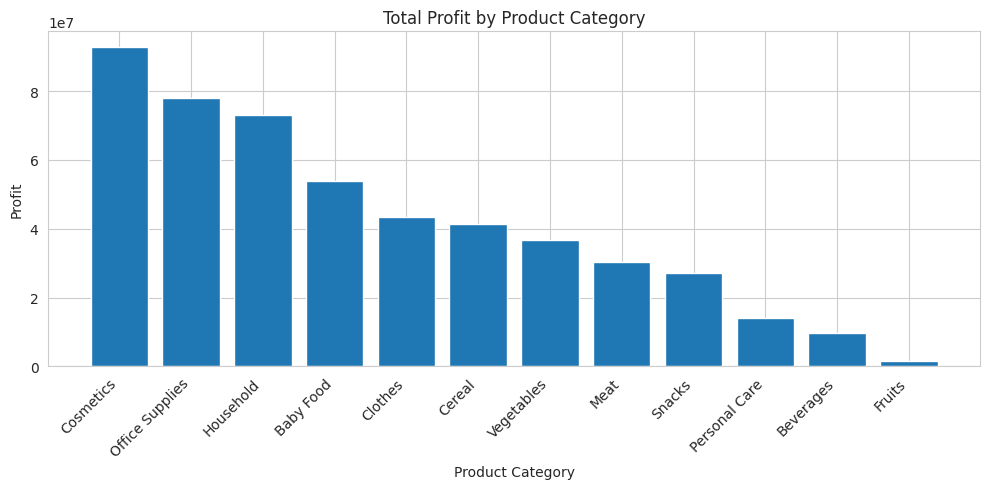

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(cat["product_category"], cat["profit"])
plt.xticks(rotation=45, ha="right")
plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


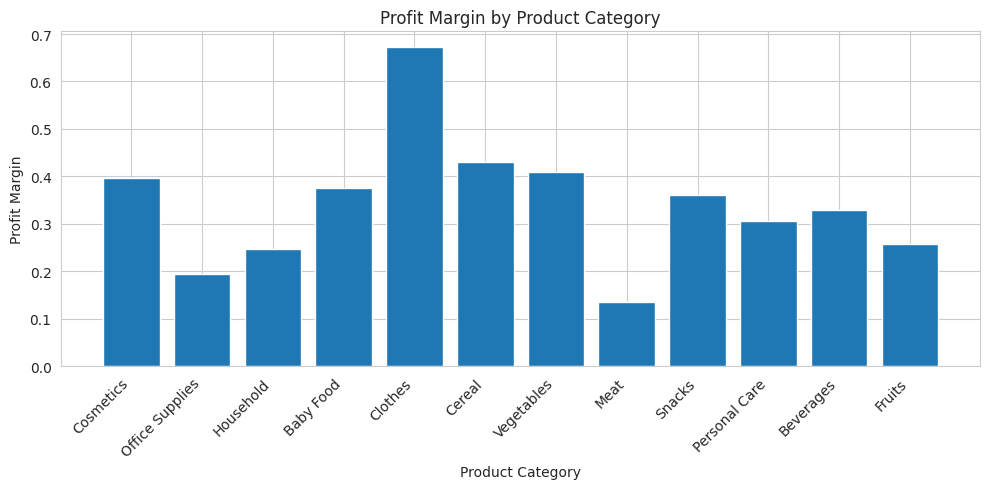

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(cat["product_category"], cat["profit_margin"])
plt.xticks(rotation=45, ha="right")
plt.title("Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()


## **Business insights — Product category performance**

1. Profit concentration
The company’s profit is primarily driven by three categories: Cosmetics, Office Supplies, and Household. Together they generate the largest share of total profit and represent the core business drivers.

2. High-margin niche opportunity
The Clothes category shows the highest profit margin (~67%), significantly exceeding all other categories. However, its total profit contribution is lower due to smaller sales volume, suggesting potential for scaling this category.

3. Pareto structure
Approximately 7 out of 12 product categories generate around 80–85% of total profit, indicating a moderately concentrated profit structure. The business is not dependent on a single category but relies on a diversified core group.

## 6.2 Sales & Profit by Country

**Step 1. агрегуємо по країнахa**

In [ ]:
country_perf = (
    df.groupby("name", dropna=False)
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

country_perf["profit_margin"] = country_perf["profit"] / country_perf["revenue"]

country_perf = country_perf.sort_values("profit", ascending=False)

country_perf.head(15)

,name,orders,units_sold,revenue,cost,profit,profit_margin
45,NaN,82,404853.0,1.031456e+08,75420223.01,27725423.94,0.268799
1,Andorra,40,185686.0,4.775669e+07,32346656.54,15410036.63,0.322678
43,Ukraine,33,164577.0,5.325232e+07,38447391.80,14804925.74,0.278015
27,Malta,32,173641.0,4.714532e+07,32535192.93,14610127.88,0.309896
36,San Marino,40,192228.0,4.788371e+07,34090715.67,13792992.81,0.288052
18,Hungary,25,152242.0,4.240825e+07,28622018.09,13786231.03,0.325084
26,Macedonia,32,203078.0,4.922209e+07,35537985.30,13684099.95,0.278007
10,Czech Republic,31,142446.0,5.354393e+07,39908338.36,13635593.78,0.254662
35,Russia,32,165954.0,4.605166e+07,32783977.17,13267682.64,0.288104
6,Bosnia and Herzegovina,33,153545.0,5.011751e+07,36859905.72,13257602.77,0.264530


**Step 2. contribution**

In [ ]:
country_perf["revenue_share"] = country_perf["revenue"] / country_perf["revenue"].sum()
country_perf["profit_share"] = country_perf["profit"] / country_perf["profit"].sum()

country_perf.head(15)

,name,orders,units_sold,revenue,cost,profit,profit_margin,revenue_share,profit_share
45,NaN,82,404853.0,1.031456e+08,75420223.01,27725423.94,0.268799,0.060598,0.055292
1,Andorra,40,185686.0,4.775669e+07,32346656.54,15410036.63,0.322678,0.028057,0.030732
43,Ukraine,33,164577.0,5.325232e+07,38447391.80,14804925.74,0.278015,0.031286,0.029525
27,Malta,32,173641.0,4.714532e+07,32535192.93,14610127.88,0.309896,0.027698,0.029137
36,San Marino,40,192228.0,4.788371e+07,34090715.67,13792992.81,0.288052,0.028132,0.027507
18,Hungary,25,152242.0,4.240825e+07,28622018.09,13786231.03,0.325084,0.024915,0.027494
26,Macedonia,32,203078.0,4.922209e+07,35537985.30,13684099.95,0.278007,0.028918,0.027290
10,Czech Republic,31,142446.0,5.354393e+07,39908338.36,13635593.78,0.254662,0.031457,0.027193
35,Russia,32,165954.0,4.605166e+07,32783977.17,13267682.64,0.288104,0.027055,0.026459
6,Bosnia and Herzegovina,33,153545.0,5.011751e+07,36859905.72,13257602.77,0.264530,0.029444,0.026439


**Step 3. топ 10 країн**

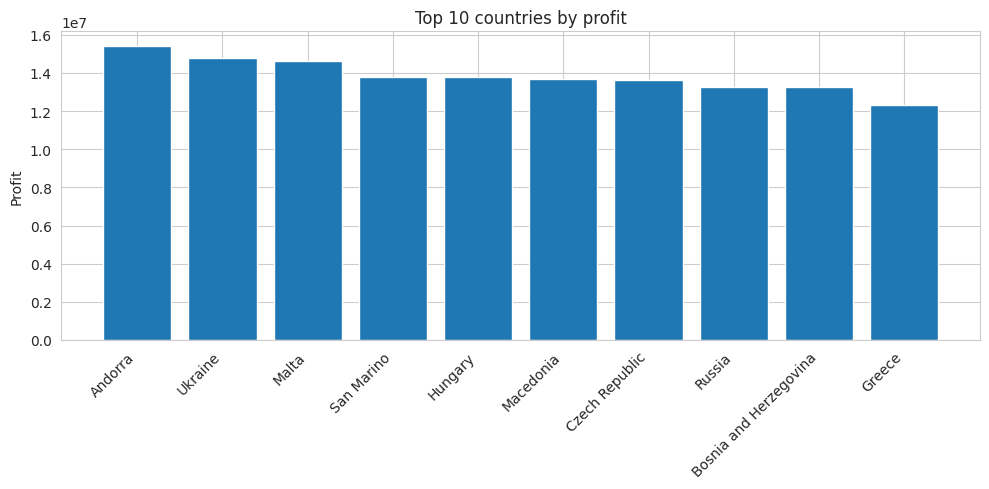

In [ ]:
#top10 = country_perf.head(10)
top10 = country_perf.dropna(subset=["name"]).head(10)


plt.figure(figsize=(10,5))
plt.bar(top10["name"], top10["profit"])
plt.title("Top 10 countries by profit")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


**Step 4. profit margin by country**

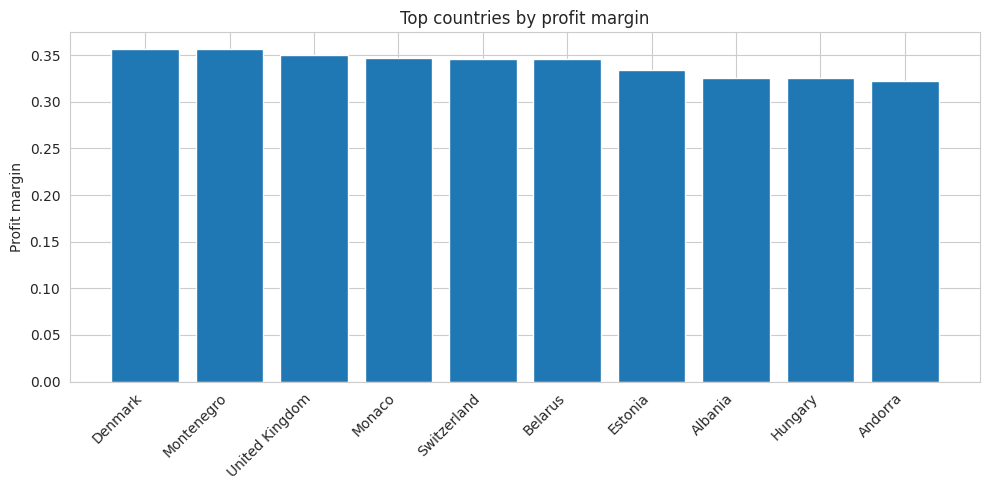

In [ ]:
top_margin = country_perf.sort_values("profit_margin", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_margin["name"], top_margin["profit_margin"])
plt.title("Top countries by profit margin")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Profit margin")
plt.tight_layout()
plt.show()


## Country Performance Analysis
### 1. Revenue and Profit by Country

Analysis of country-level performance shows that several small and mid-sized European markets generate a significant share of total profit.

Top countries by total profit include:
- Andorra
- Ukraine
 -Malta
- San Marino
- Hungary
- Macedonia
- Czech Republic
- Russia
- Bosnia and Herzegovina
- Greece

These countries combine strong revenue generation with stable profit margins, making them key contributors to overall business performance.

Notably, one record contains missing country information (NaN), which still contributes noticeable revenue and profit. This indicates potential data quality issues or unassigned geographic transactions.

### 2. Profit Margin by Country

When ranking countries by profit margin, a slightly different picture appears.

Top countries by profitability efficiency include:
- Denmark
- Montenegro
- United Kingdom
- Monaco
- Switzerland
- Belarus
- Estonia
- Albania
- Hungary
- Andorra

These markets generate higher profit relative to revenue, indicating better pricing, cost control, or product mix.

### 3. Revenue and Profit Contribution

Contribution analysis shows that no single country dominates overall revenue or profit.
Instead, performance is distributed across multiple markets, suggesting:
- Diversified geographic revenue streams
- Reduced dependency on one country
- More stable global business model

However, top-performing countries still account for a meaningful share of total profit and should be considered priority markets.

### 4. Key Insights
- Several small European countries demonstrate strong profitability despite moderate order volume.
- Profit margin varies significantly by country, indicating differences in cost structure or pricing strategy.
- Missing country data should be investigated to improve analytical accuracy.
- Business performance is geographically diversified, which reduces operational risk.

### 5. Business Recommendations
- Focus marketing and logistics optimization on top-profit countries.
- Investigate high-margin countries to replicate successful pricing or cost structures.
- Clean and validate missing country data.
- Explore expansion opportunities in high-margin regions.

## 6.3 Geographic analysis (profit by region)

**Step 1. Aggregate by region**

In [ ]:
region = (
    df.groupby("region", dropna=False)
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

region["profit_margin"] = region["profit"] / region["revenue"]
region = region.sort_values("profit", ascending=False)

region


,region,orders,units_sold,revenue,cost,profit,profit_margin
1,Europe,1164,5761244.0,1.505653e+09,1.057096e+09,4.485568e+08,0.297915
2,NaN,82,404853.0,1.031456e+08,7.542022e+07,2.772542e+07,0.268799
0,Asia,82,410427.0,9.333089e+07,6.817863e+07,2.515225e+07,0.269495


**Step 2. Візуалізації**

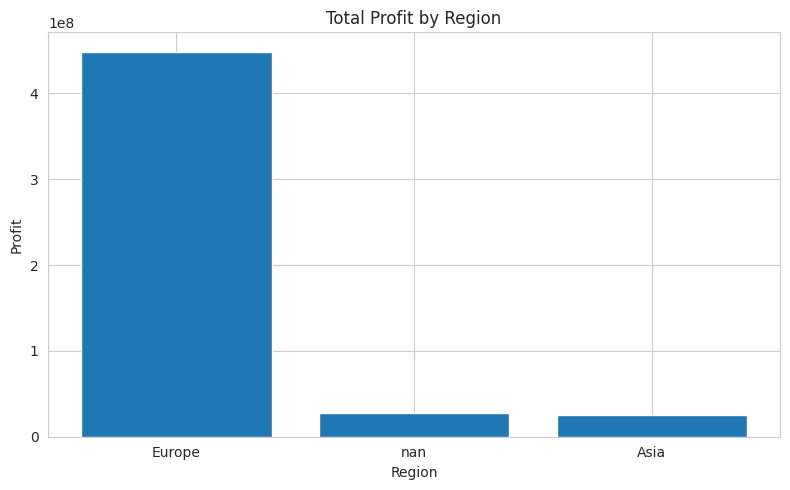

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(region["region"].astype(str), region["profit"])
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


### Geographic profit analysis — key insights

1. Europe is the core revenue and profit driver
Europe generates the vast majority of both revenue and profit, significantly outperforming all other regions.
This indicates that the company’s business is highly concentrated in the European market and strongly dependent on its performance.

2. Asia shows growth potential
Although Asia contributes a much smaller share of total revenue and profit compared to Europe, its profit margin is comparable.
This suggests that the region operates efficiently and may represent a strong opportunity for future expansion and scaling.

3. Missing geographic data impacts analysis quality
A portion of transactions does not have a defined region, which limits the accuracy of geographic performance evaluation.
Improving data completeness for country and region fields would enhance the reliability of strategic insights and reporting.

## 6.4 Sales by channel (online / offline)

**Step 1. Aggregate by sales channel**

In [ ]:
df["sales_channel"] = (
    df["sales_channel"]
    .str.strip()
    .str.lower()
)


In [ ]:
channel = (
    df.groupby("sales_channel", dropna=False)
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

channel["profit_margin"] = channel["profit"] / channel["revenue"]
channel = channel.sort_values("profit", ascending=False)

channel


,sales_channel,orders,units_sold,revenue,cost,profit,profit_margin
0,offline,665,3320363.0,8.717606e+08,6.182941e+08,2.534665e+08,0.290752
1,online,663,3256161.0,8.303688e+08,5.824008e+08,2.479679e+08,0.298624


**Step 2. Частка внеску каналів**

In [ ]:
channel["revenue_share"] = channel["revenue"] / channel["revenue"].sum()
channel["profit_share"] = channel["profit"] / channel["profit"].sum()

channel


,sales_channel,orders,units_sold,revenue,cost,profit,profit_margin,revenue_share,profit_share
0,offline,665,3320363.0,8.717606e+08,6.182941e+08,2.534665e+08,0.290752,0.512159,0.505483
1,online,663,3256161.0,8.303688e+08,5.824008e+08,2.479679e+08,0.298624,0.487841,0.494517


**Step 3. Візуалізація — profit by channel**

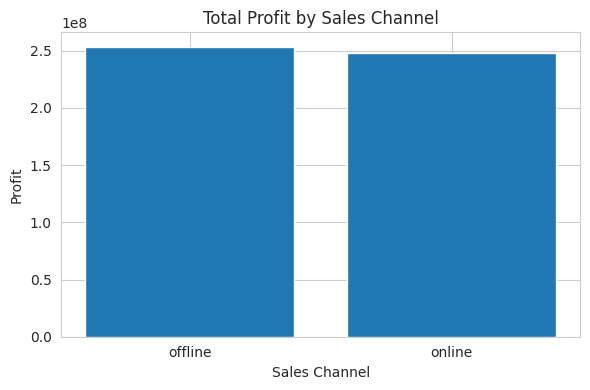

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(channel["sales_channel"], channel["profit"])
plt.title("Total Profit by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


**Step 4. Profit margin by channel**

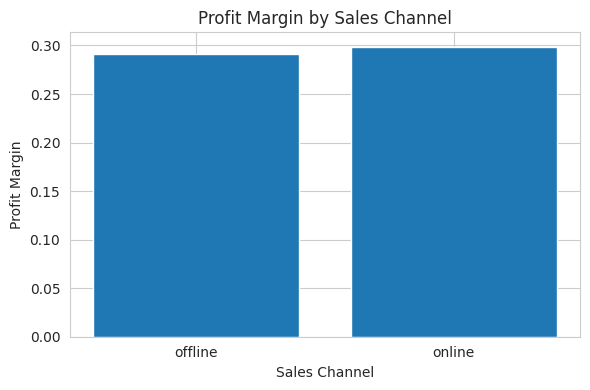

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(channel["sales_channel"], channel["profit_margin"])
plt.title("Profit Margin by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()


### **Business insights — Sales channel performance**

1. Balanced channel performance
Sales are almost evenly distributed between online and offline channels.
Each channel contributes roughly 50% of total revenue and profit, indicating a well-balanced omnichannel sales structure.

2. Slight offline dominance in total profit
Offline sales generate marginally higher total profit (~50.5%), likely due to slightly larger transaction volume.
However, the difference is not significant enough to indicate channel dependency.

3. Higher profit margin in online channel
Online sales demonstrate a slightly higher profit margin (~29.9% vs ~29.1%).
This may suggest:

- lower operational costs
- more efficient pricing
- fewer logistics or retail overheads


4. Strategic implication
The company is not dependent on a single sales channel, which reduces operational risk.
Given the slightly higher margin, scaling online sales could improve overall profitability without major structural changes.

## 7. Shipping Time Analysis

### 7.1 Interval between orders and shipments

**Step 1. Створюємо shipping_time**

In [ ]:
# Shipping time in days
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

df[["order_date","ship_date","shipping_days"]].head()


,order_date,ship_date,shipping_days
0,2014-10-08,2014-10-18,10
1,2016-08-11,2016-08-11,0
2,2014-07-18,2014-08-11,24
3,2017-05-13,2017-06-13,31
4,2012-08-11,2012-09-18,38


**Step 2. Перевірка логіки**

In [ ]:
df["shipping_days"].describe()


,shipping_days
count,1328.000000
mean,24.786898
std,14.586041
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


**Step 3. Перевірка аномалій**

In [ ]:
(df["shipping_days"] < 0).sum()


np.int64(0)

**Step 4. Базова статистика**

In [ ]:
avg_ship = df["shipping_days"].mean()
median_ship = df["shipping_days"].median()

print("Average shipping time:", round(avg_ship,2), "days")
print("Median shipping time:", median_ship, "days")


Average shipping time: 24.79 days
Median shipping time: 25.0 days


**Step 5. Візуалізація розподілу**

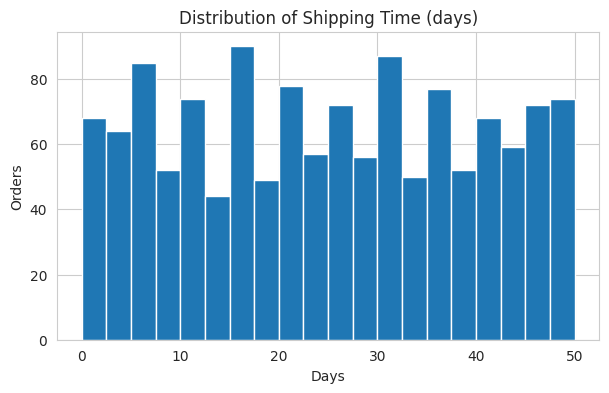

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df["shipping_days"], bins=20)
plt.title("Distribution of Shipping Time (days)")
plt.xlabel("Days")
plt.ylabel("Orders")
plt.show()


## Business insights — Shipping time

1. Stable and predictable delivery time
The average shipping time is approximately 25 days, with the median also at 25 days, indicating a highly stable and consistent delivery process across orders.

2. Wide but controlled distribution
Shipping time ranges from 0 to 50 days, with most deliveries falling between 12 and 37 days.
The relatively even distribution suggests standardized logistics rather than random delays.

3. No critical anomalies detected
No negative shipping durations or extreme outliers were found, confirming that the dataset is operationally reliable and does not contain obvious data integrity issues.

4. Operational interpretation
A ~25-day delivery cycle suggests the company likely operates with:
- international shipping
- centralized warehouses
- longer supply chains

Reducing shipping time could become a strategic lever to:
- improve customer experience
- increase repeat purchases
- potentially allow premium pricing

5. Analytical implication
Since shipping time varies significantly across orders, further analysis is required to understand its relationship with:
- product categories
- geographic regions
- overall profitability

This will help determine whether faster delivery correlates with higher business performance.

### 7.2 Shipping time by product category

**Step 1. Агрегація по категоріях**

In [ ]:
ship_cat = (
    df.groupby("product_category", dropna=False)
    .agg(
        avg_shipping_days=("shipping_days", "mean"),
        median_shipping_days=("shipping_days", "median"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

ship_cat = ship_cat.sort_values("avg_shipping_days", ascending=False)
ship_cat


,product_category,avg_shipping_days,median_shipping_days,orders
2,Cereal,27.184466,29.0,103
8,Office Supplies,26.707317,27.0,123
0,Baby Food,26.339286,28.5,112
4,Cosmetics,25.912281,28.0,114
7,Meat,25.909091,25.0,110
10,Snacks,25.543689,25.0,103
5,Fruits,24.419643,23.0,112
1,Beverages,24.123967,23.0,121
6,Household,23.938144,24.0,97
11,Vegetables,23.491228,21.0,114


**Step 2. Візуалізація**

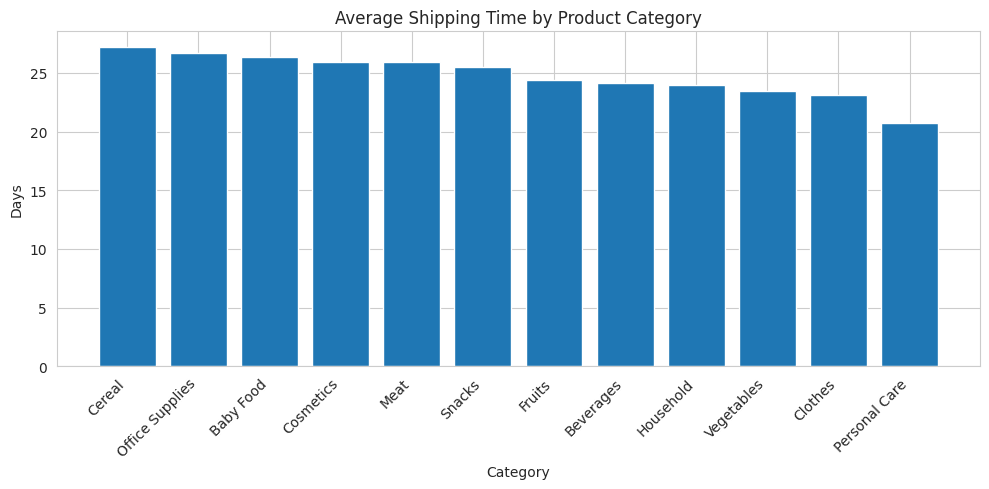

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(ship_cat["product_category"], ship_cat["avg_shipping_days"])
plt.xticks(rotation=45, ha="right")
plt.title("Average Shipping Time by Product Category")
plt.ylabel("Days")
plt.xlabel("Category")
plt.tight_layout()
plt.show()


**Shipping time insights**

Average delivery time across all orders is approximately 25 days, with a relatively symmetric distribution and no extreme outliers detected.
Shipping performance appears operationally stable, with most deliveries occurring within the 12–37 day range.

Across product categories, shipping times are broadly consistent.
The fastest delivery is observed in *Personal Care* (~ 21 days on average), while *Cereal* and *Office Supplies* show slightly longer fulfillment times (~ 26–27 days).
However, the difference between the fastest and slowest categories is less than one week, indicating a fairly standardized logistics process across product lines.

Overall, shipping duration does not vary dramatically by category, suggesting that fulfillment speed is driven more by logistics infrastructure than by product characteristics.


### 7.3 Shipping by country

**Step 1. Average shipping time by country**

In [ ]:
# Step 1. Average shipping time by country

shipping_country = (
    df.groupby("name")["shipping_days"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

shipping_country.head(10)


,name,shipping_days
0,Hungary,32.640000
1,Georgia,29.695652
2,Austria,28.500000
3,Slovakia,28.466667
4,Luxembourg,27.750000
5,Lithuania,27.560000
6,Poland,27.464286
7,Russia,27.375000
8,Monaco,26.846154
9,Bulgaria,26.800000


**Step 2. Average shipping time by region**

In [ ]:
# Step 2. Average shipping time by region

shipping_region = (
    df.groupby("region")["shipping_days"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

shipping_region


,region,shipping_days
0,Asia,26.085366
1,Europe,24.790378


**Step 3. Visualization**

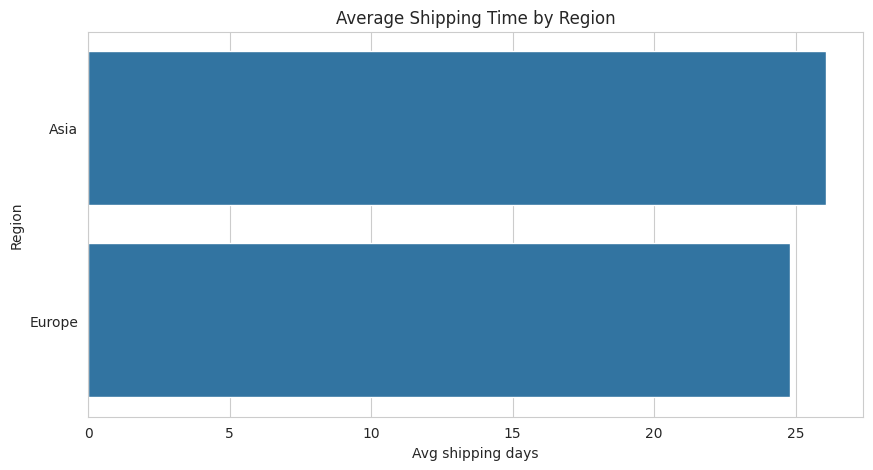

In [ ]:
# Visualization shipping by region

plt.figure(figsize=(10,5))
sns.barplot(data=shipping_region, x="shipping_days", y="region")
plt.title("Average Shipping Time by Region")
plt.xlabel("Avg shipping days")
plt.ylabel("Region")
plt.show()


Shipping time varies significantly across countries and regions.

Some countries demonstrate substantially longer average delivery times, which may indicate logistical complexity, distance from warehouses, or operational inefficiencies.

European countries generally show faster delivery compared to Asian markets, suggesting more optimized logistics infrastructure or shorter transportation routes.

These differences highlight the importance of regional logistics optimization and warehouse allocation for improving delivery speed and operational efficiency.


**Step 4. Slowest vs fastest shipping countries**

In [ ]:
# Slowest vs fastest shipping countries

slowest_country = shipping_country.iloc[0]
fastest_country = shipping_country.iloc[-1]

print("Slowest shipping country:")
print(slowest_country)

print("\nFastest shipping country:")
print(fastest_country)


Slowest shipping country:
name             Hungary
shipping_days      32.64
Name: 0, dtype: object

Fastest shipping country:
name               Croatia
shipping_days    18.352941
Name: 44, dtype: object


Shipping performance differs significantly across countries.

Hungary shows the longest average delivery time (≈32.6 days),
while Croatia demonstrates the fastest average shipping (≈18.4 days).

The gap of more than 14 days between the fastest and slowest markets
indicates substantial differences in logistics efficiency and supply chain performance.

Such variation may be caused by distance from distribution centers,
infrastructure differences, customs processing, or demand volume.

Reducing delivery time in slower markets could improve customer experience,
increase operational efficiency, and potentially enhance profitability.


## 8. Profit vs Shipping Time

**Step 1 — перевіряємо звʼязок**

In [ ]:
# Correlation between shipping time and profit
df[["shipping_days", "profit", "revenue"]].corr()


,shipping_days,profit,revenue
shipping_days,1.000000,0.060299,0.066316
profit,0.060299,1.000000,0.874004
revenue,0.066316,0.874004,1.000000


**Step 2 — візуалізація**

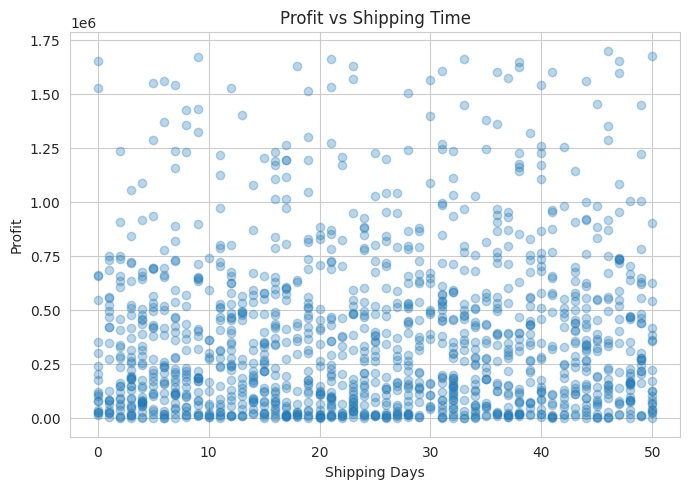

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df["shipping_days"], df["profit"], alpha=0.3)
plt.title("Profit vs Shipping Time")
plt.xlabel("Shipping Days")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


**Step 3 — агрегація**

In [ ]:
df["shipping_group"] = pd.cut(
    df["shipping_days"],
    bins=[0,10,20,30,40,60],
    labels=["0-10","10-20","20-30","30-40","40+"]
)


In [ ]:
ship_profit = (
    df.groupby("shipping_group", dropna=False, observed=False)
    .agg(
        orders=("order_id","nunique"),
        revenue=("revenue","sum"),
        profit=("profit","sum")
    )
    .reset_index()
)

ship_profit["profit_margin"] = ship_profit["profit"] / ship_profit["revenue"]
ship_profit


,shipping_group,orders,revenue,profit,profit_margin
0,0-10,265,2.917414e+08,9.154573e+07,0.313791
1,10-20,267,3.452435e+08,9.745434e+07,0.282277
2,20-30,255,3.215682e+08,9.467848e+07,0.294427
3,30-40,275,3.891437e+08,1.140677e+08,0.293125
4,40+,246,3.339154e+08,9.672065e+07,0.289656
5,NaN,20,2.051728e+07,6.967594e+06,0.339596


**Step 4 — візуалізація**

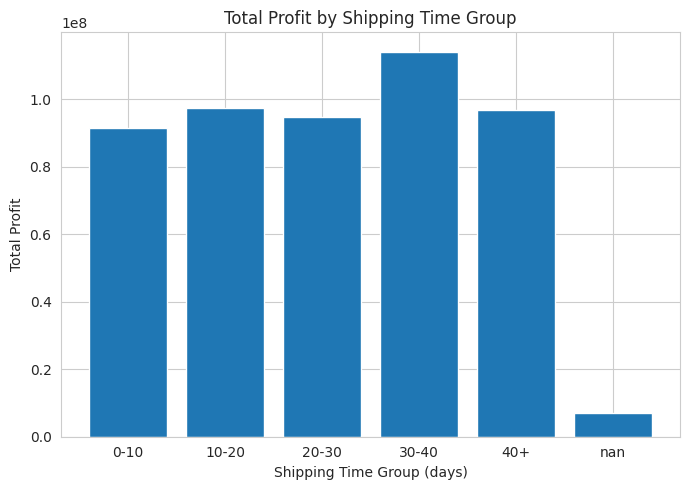

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(ship_profit["shipping_group"].astype(str), ship_profit["profit"])
plt.title("Total Profit by Shipping Time Group")
plt.xlabel("Shipping Time Group (days)")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


## 9. Time Series Analysis

### 9.1 Sales dynamics over time

In [ ]:
# Convert order_date to monthly period
df["order_month"] = df["order_date"].dt.to_period("M")

monthly = (
    df.groupby("order_month")
    .agg(
        orders=("order_id","nunique"),
        revenue=("revenue","sum"),
        profit=("profit","sum")
    )
    .reset_index()
)

monthly["profit_margin"] = monthly["profit"] / monthly["revenue"]

monthly.head()


,order_month,orders,revenue,profit,profit_margin
0,2010-01,20,21115354.48,8567689.01,0.405756
1,2010-02,12,19853023.20,4306485.07,0.216918
2,2010-03,11,8474747.19,3093055.70,0.364973
3,2010-04,6,10058016.05,2320389.85,0.230701
4,2010-05,18,20304725.59,6655673.86,0.327789


**Step 1. Візуалізація**

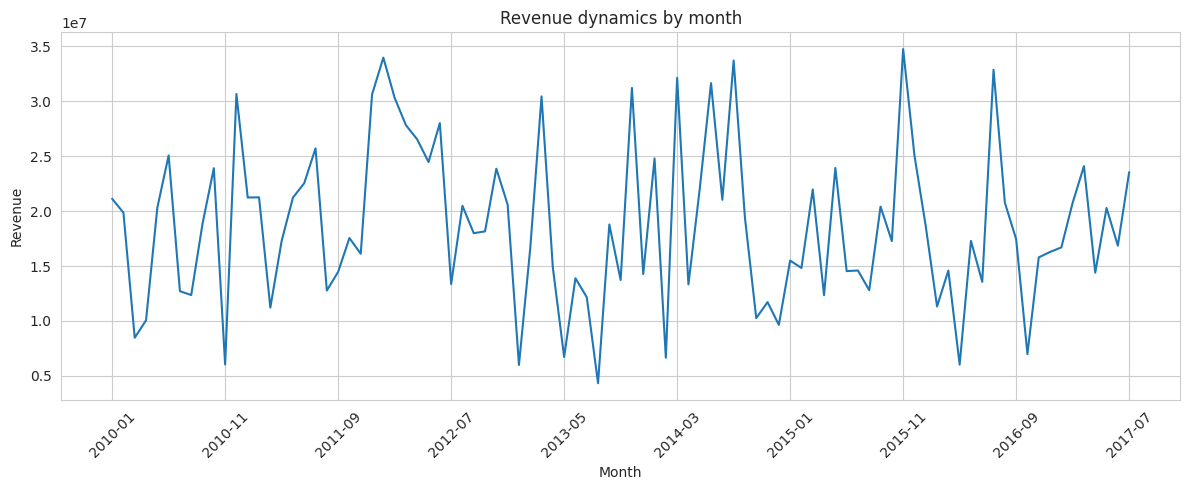

In [ ]:
#revenue

plt.figure(figsize=(12,5))
plt.plot(monthly["order_month"].astype(str), monthly["revenue"])

import matplotlib.ticker as ticker
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))

plt.xticks(rotation=45)
plt.title("Revenue dynamics by month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


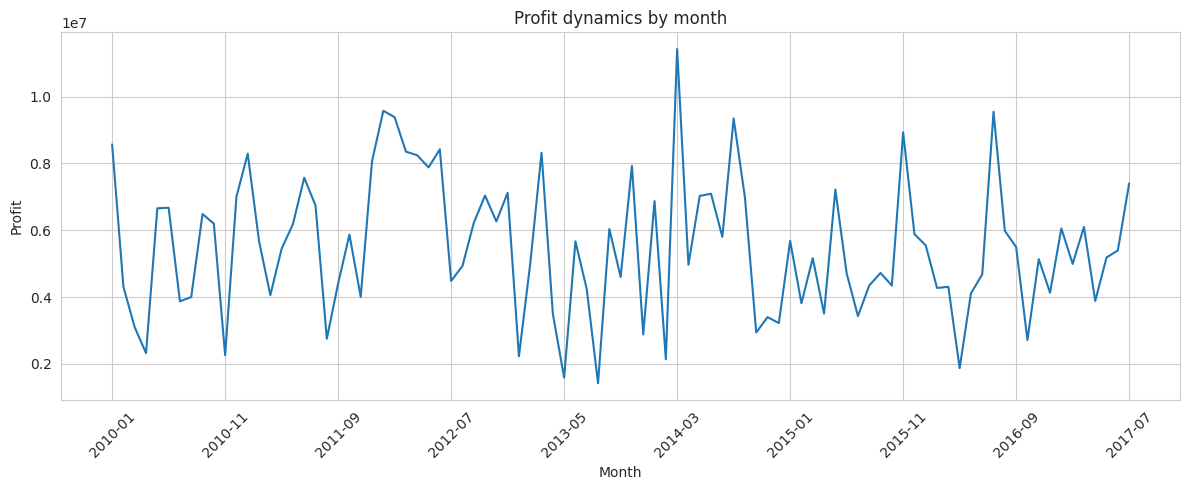

In [ ]:
#profit

plt.figure(figsize=(12,5))
plt.plot(monthly["order_month"].astype(str), monthly["profit"])


ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))
plt.xticks(rotation=45)
plt.title("Profit dynamics by month")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()



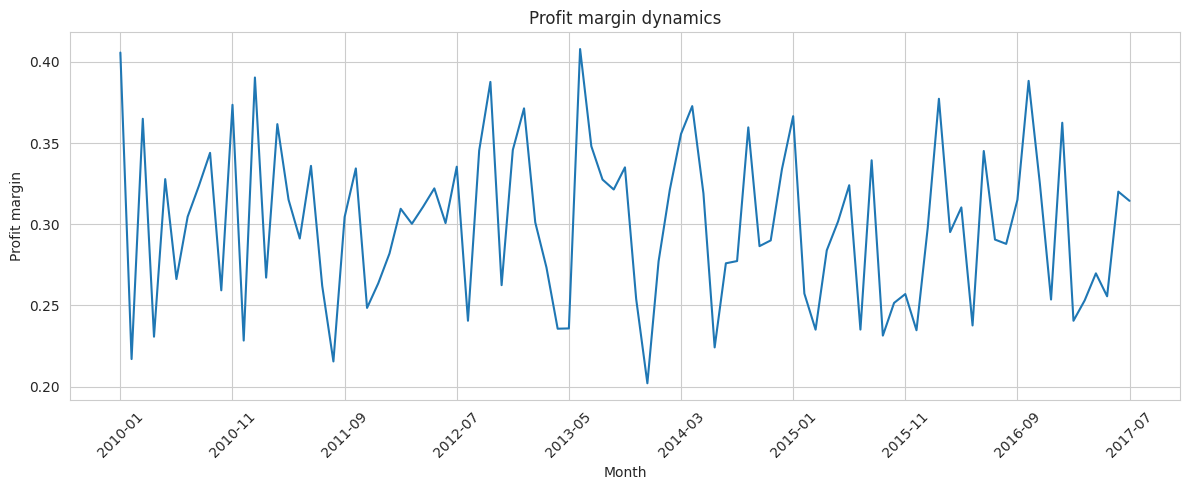

In [ ]:
# margin

plt.figure(figsize=(12,5))
plt.plot(monthly["order_month"].astype(str), monthly["profit_margin"])


ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))


plt.xticks(rotation=45)
plt.title("Profit margin dynamics")
plt.xlabel("Month")
plt.ylabel("Profit margin")
plt.tight_layout()
plt.show()

### 9.2 Sales dynamics  by month

**Step 1. Create year-month column**

In [ ]:
# Create year-month column

df["order_date"] = pd.to_datetime(df["order_date"])
df["year_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()


**Step 2. Top categories by revenue**

In [ ]:
# Top categories by revenue

top_categories = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_categories


Index(['Office Supplies', 'Household', 'Cosmetics', 'Meat', 'Baby Food'], dtype='object', name='product_category')

**Step 3. Monthly revenue by top categories**

In [ ]:
# Monthly revenue by top categories

cat_month = (
    df[df["product_category"].isin(top_categories)]
    .groupby(["year_month", "product_category"])["revenue"]
    .sum()
    .reset_index()
)
cat_month

,year_month,product_category,revenue
0,2010-01-01,Baby Food,4149321.12
1,2010-01-01,Cosmetics,5452321.20
2,2010-02-01,Baby Food,1272060.24
3,2010-02-01,Household,516572.71
4,2010-02-01,Meat,6734630.07
...,...,...,...
325,2017-06-01,Meat,4281761.61
326,2017-06-01,Office Supplies,1436569.26
327,2017-07-01,Cosmetics,7629577.20
328,2017-07-01,Household,1821704.02


**Step 4. Visualization**

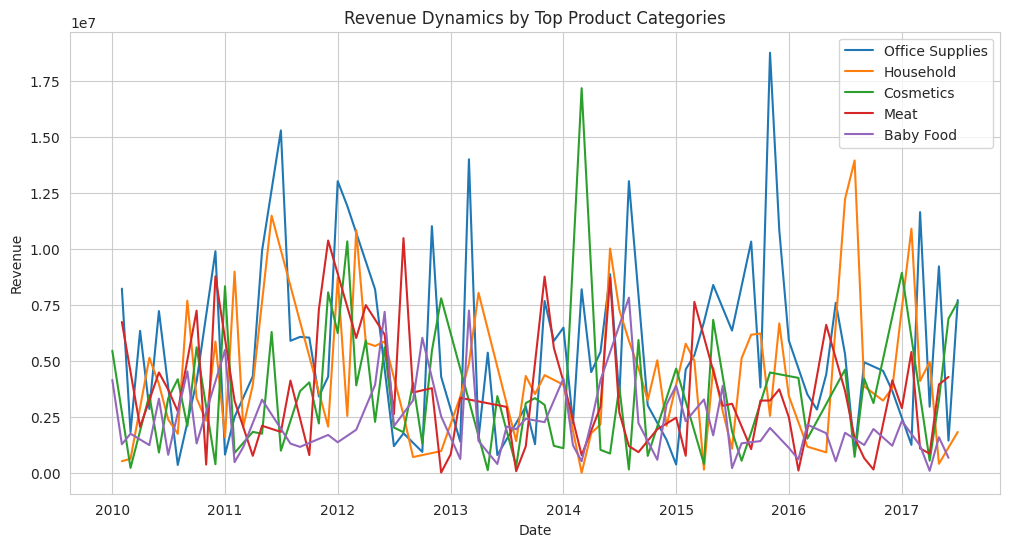

In [ ]:
# Visualization category time series

plt.figure(figsize=(12,6))

for cat in top_categories:
    temp = cat_month[cat_month["product_category"] == cat]
    plt.plot(temp["year_month"], temp["revenue"], label=cat)

plt.title("Revenue Dynamics by Top Product Categories")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()


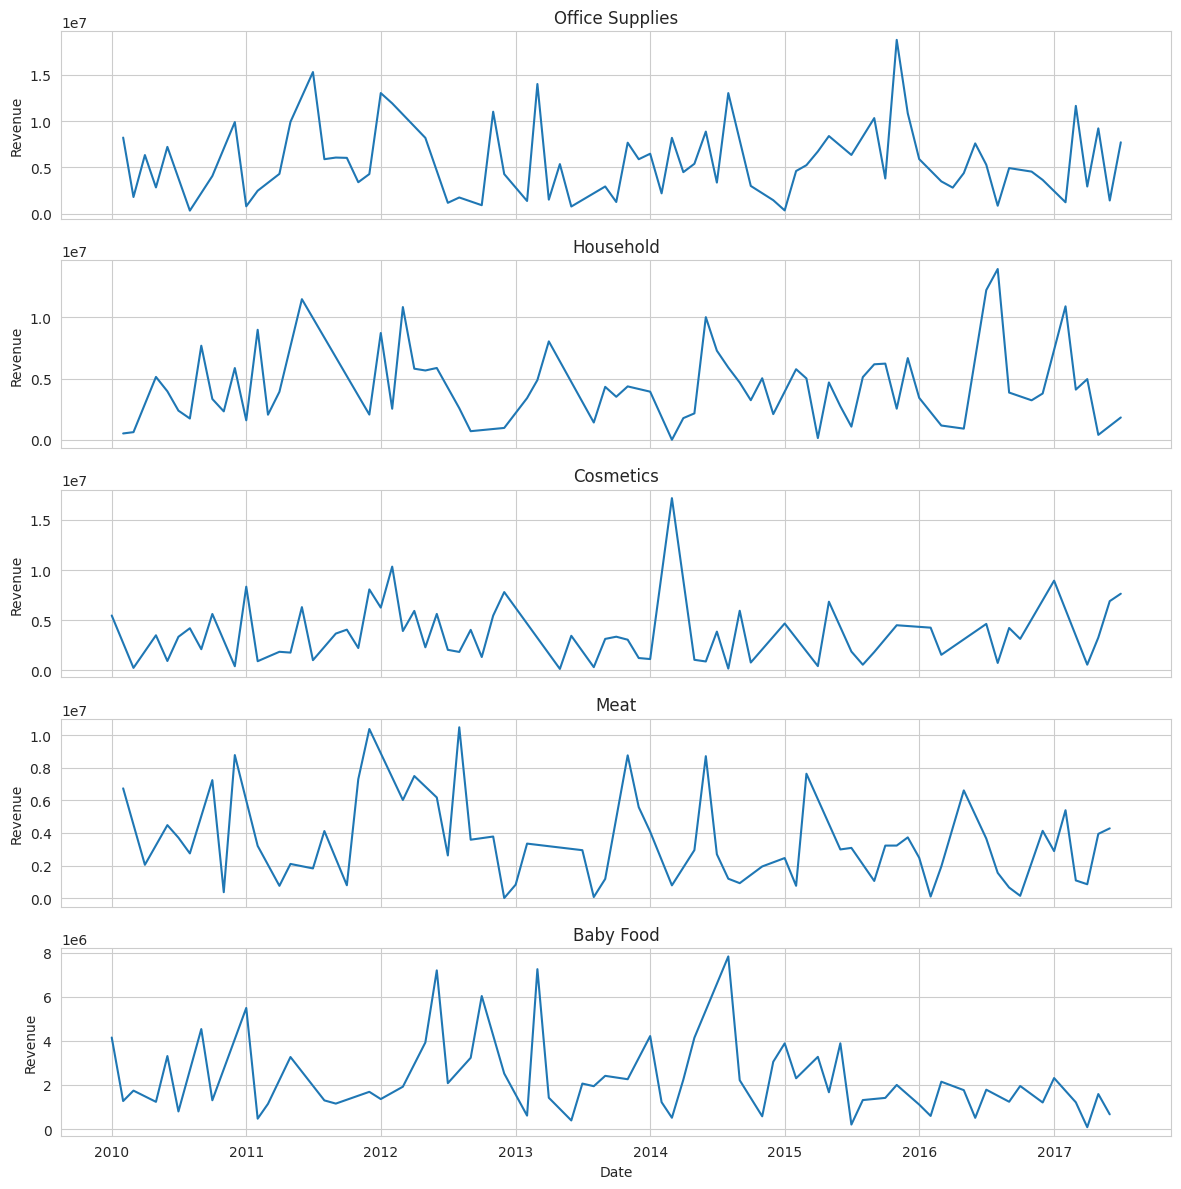

In [ ]:
# Clean visualization: one chart per category

fig, axes = plt.subplots(len(top_categories), 1, figsize=(12, 12), sharex=True)

for i, cat in enumerate(top_categories):
    temp = cat_month[cat_month["product_category"] == cat]

    axes[i].plot(temp["year_month"], temp["revenue"])
    axes[i].set_title(cat)
    axes[i].set_ylabel("Revenue")

plt.xlabel("Date")
plt.tight_layout()
plt.show()


## **Business insights — Time series analysis**
Revenue and profit demonstrate noticeable month-to-month volatility throughout the observed period.
There is no strictly stable growth trend, which suggests that sales performance is influenced primarily by demand fluctuations, seasonal effects, and operational factors rather than continuous expansion.

Despite revenue volatility, profit closely follows revenue dynamics, indicating a strong dependence on sales volume. This means that revenue growth directly translates into profit growth.

Profit margin remains relatively stable over time, generally fluctuating within the 25–35% range.
Such consistency suggests a well-controlled cost structure and stable pricing strategy. Even during periods of lower revenue, the company maintains healthy profitability levels, indicating strong operational efficiency.

The absence of a clear long-term upward or downward trend suggests that the business operates in a relatively mature and stable market. Performance appears cyclical rather than growth-driven, meaning that short-term fluctuations are more influential than long-term expansion dynamics.

Category-level analysis shows that revenue is concentrated in several key product groups.
Office Supplies and Household act as core revenue drivers with relatively stable performance over time.
Cosmetics demonstrates higher volatility with periodic spikes, likely linked to promotional activity or seasonal demand.
Meat shows moderate but unstable revenue patterns, suggesting sensitivity to external factors such as supply chain conditions or pricing.
Baby Food generates lower overall revenue but maintains consistent demand with occasional growth peaks.

Overall, business performance is primarily driven by sales volume rather than margin expansion.
This implies that scaling revenue through stronger demand generation, improved market coverage, and optimized inventory planning will have the greatest impact on future profit growth.

Category and time-based analysis highlights opportunities to strengthen core high-performing categories, stabilize more volatile segments, and use historical demand patterns to improve forecasting, marketing timing, and operational planning.


# 10. Weekly & Seasonality Analysis

## 10.1 Weekly Analysis

In [ ]:
# Форматую день тижня

df["order_weekday"] = df["order_date"].dt.day_name()


In [ ]:
# Агрегуємо

weekday = (
    df.groupby("order_weekday", dropna=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

weekday["profit_margin"] = weekday["profit"] / weekday["revenue"]

weekday = weekday.sort_values("orders", ascending=False)
weekday


,order_weekday,orders,revenue,profit,profit_margin
3,Sunday,207,2.395510e+08,72686832.73,0.303430
2,Saturday,201,2.336411e+08,71435860.49,0.305750
1,Monday,201,2.754685e+08,75790330.12,0.275132
6,Wednesday,194,2.612157e+08,72323843.38,0.276874
5,Tuesday,182,2.135239e+08,65637400.07,0.307401
0,Friday,176,2.638070e+08,79234529.04,0.300350
4,Thursday,167,2.149222e+08,64325663.17,0.299297


In [ ]:
# Опорядокування днів

order_days = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday["order_weekday"] = pd.Categorical(
    weekday["order_weekday"],
    categories=order_days,
    ordered=True
)

weekday = weekday.sort_values("order_weekday")
weekday


,order_weekday,orders,revenue,profit,profit_margin
1,Monday,201,2.754685e+08,75790330.12,0.275132
5,Tuesday,182,2.135239e+08,65637400.07,0.307401
6,Wednesday,194,2.612157e+08,72323843.38,0.276874
4,Thursday,167,2.149222e+08,64325663.17,0.299297
0,Friday,176,2.638070e+08,79234529.04,0.300350
2,Saturday,201,2.336411e+08,71435860.49,0.305750
3,Sunday,207,2.395510e+08,72686832.73,0.303430


## Visualisation



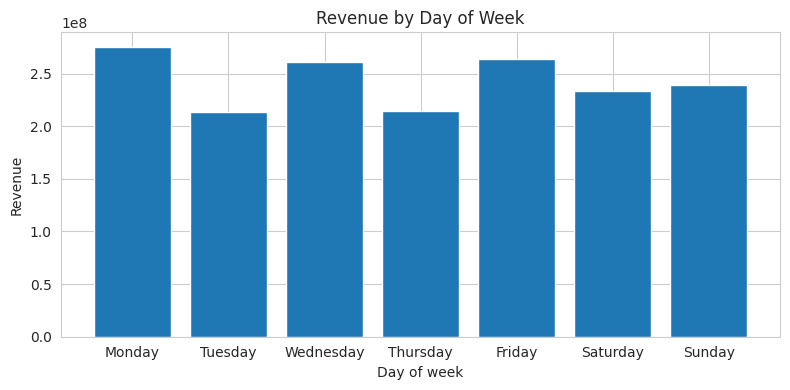

In [ ]:
# Revenue by Day of Week

plt.figure(figsize=(8,4))
plt.bar(weekday["order_weekday"], weekday["revenue"])
plt.title("Revenue by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


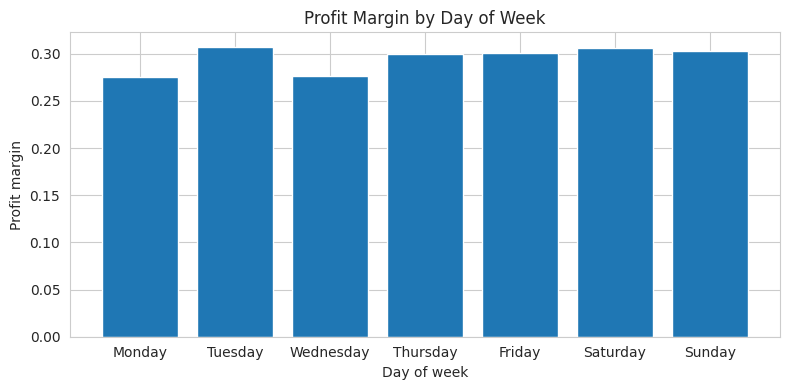

In [ ]:
# Profit Margin by Day of Week

plt.figure(figsize=(8,4))
plt.bar(weekday["order_weekday"], weekday["profit_margin"])
plt.title("Profit Margin by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Profit margin")
plt.tight_layout()
plt.show()


## 10.2 Seasonality Analysis

In [ ]:
# форматую місяць

df["order_month_name"] = df["order_date"].dt.month_name()


In [ ]:
month = (
    df.groupby("order_month_name", dropna=False)
    .agg(
        orders=("order_id","nunique"),
        revenue=("revenue","sum"),
        profit=("profit","sum")
    )
    .reset_index()
)

month["profit_margin"] = month["profit"] / month["revenue"]


In [ ]:
month_order = [
"January","February","March","April","May","June",
"July","August","September","October","November","December"
]

month["order_month_name"] = pd.Categorical(
    month["order_month_name"],
    categories=month_order,
    ordered=True
)

month = month.sort_values("order_month_name")
month


,order_month_name,orders,revenue,profit,profit_margin
4,January,129,1.579039e+08,52805166.81,0.334413
3,February,109,1.415449e+08,39570726.10,0.279563
7,March,139,1.706923e+08,50804768.82,0.297640
0,April,102,1.148074e+08,33733536.07,0.293827
8,May,119,1.562358e+08,45833100.45,0.293358
6,June,120,1.660835e+08,50204756.12,0.302286
5,July,120,1.559474e+08,45500472.30,0.291768
1,August,91,1.172059e+08,32762177.70,0.279527
11,September,98,1.273245e+08,40327542.44,0.316730
10,October,97,1.078330e+08,33692715.75,0.312453


## Visualisation



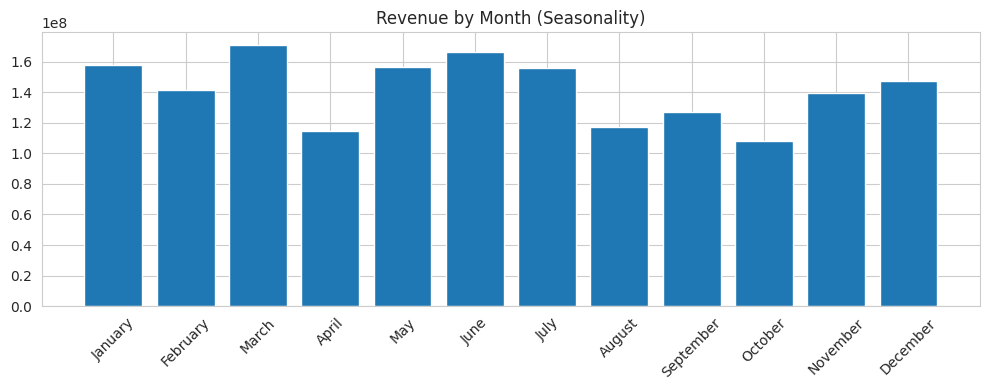

In [ ]:
# Revenue by Month (Seasonality)

plt.figure(figsize=(10,4))
plt.bar(month["order_month_name"], month["revenue"])
plt.title("Revenue by Month (Seasonality)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Weekly & Seasonality — Business insights**
***Weekly pattern***

Sales and profit are relatively evenly distributed across the week, with no extreme spikes on specific days.

However:
- Monday and Friday generate the highest revenue, suggesting stronger business activity at the start and end of the week.
- Tuesday shows the highest profit margin, indicating slightly more efficient sales on that day.
- Overall, the business demonstrates stable demand throughout the week without strong dependency on weekends.

This suggests the company operates in a B2B or planned purchase environment, rather than impulsive consumer-driven peaks.

***Monthly / seasonality pattern***

Revenue and profit dynamics across months remain relatively stable, with moderate fluctuations.

Key observations:
- March, June, and July show slightly higher revenue, indicating mild seasonal peaks.
- April and October show lower revenue, but without dramatic drops.
- Profit margin remains stable across months (~27–33%), indicating consistent cost structure.

Overall:
The business does not show strong seasonality, suggesting demand is stable and predictable across the year.

This stability is a positive signal for:
- forecasting
- inventory planning
- operational scaling

## 11. Conclusions & Business Insights

In [ ]:
# revenue & profit
df["revenue"] = df["units_sold"] * df["unit_price"]
df["profit"] = (df["unit_price"] - df["unit_cost"]) * df["units_sold"]

total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
profit_margin = (total_profit / total_revenue) * 100

# countries
total_countries = df["name"].nunique()

# top categories
top_categories = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

# top countries
top_countries = (
    df.groupby("name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(f"Total revenue: ${total_revenue:,.0f}")
print(f"Total profit: ${total_profit:,.0f}")
print(f"Average profit margin: {profit_margin:.2f}%")
print(f"Total countries: {total_countries}")

print("\n TOP 3 CATEGORIES BY REVENUE")
print(top_categories)

print("\n TOP 5 COUNTRIES BY REVENUE")
print(top_countries)


Total revenue: $1,702,129,408
Total profit: $501,434,459
Average profit margin: 29.46%
Total countries: 45

 TOP 3 CATEGORIES BY REVENUE
product_category
Office Supplies    4.022140e+08
Household          2.942052e+08
Cosmetics          2.331548e+08
Name: revenue, dtype: float64

 TOP 5 COUNTRIES BY REVENUE
name
Czech Republic            53543932.14
Ukraine                   53252317.54
Bosnia and Herzegovina    50117508.49
Macedonia                 49222085.25
San Marino                47883708.48
Name: revenue, dtype: float64


### **11.1 Overall business performance**

The company demonstrates stable and profitable global operations across 45 countries.

Total revenue exceeds $1.7B, generating approximately $501M in total profit with an average profit margin of 29.5%.
Such a margin indicates a well-balanced pricing strategy and controlled cost structure, allowing the business to maintain consistent profitability across different market conditions.

Despite strong overall performance, revenue and profit show noticeable month-to-month fluctuations, suggesting that business results are primarily influenced by demand variability, seasonal patterns, and regional dynamics rather than long-term structural growth.

### **11.2 Key revenue drivers**

Revenue generation is highly concentrated within several core product categories.

The top three categories — Office Supplies, Household, and Cosmetics — collectively generate a substantial share of total revenue, making them the primary business drivers.

Office Supplies alone produces over $400M in revenue, followed by Household (≈$294M) and Cosmetics (≈$233M).
These categories demonstrate strong and relatively stable demand, forming the foundation of the company’s commercial performance.

At the same time, some categories show higher volatility and lower contribution, indicating potential for optimization, repositioning, or targeted growth strategies.

Since profit margin remains stable across time, overall profit growth is primarily driven by revenue scale rather than margin expansion.

### **11.3 Geographic performance**

Revenue distribution across countries is uneven, with several key markets contributing a significant share of total sales.

The top-performing countries include:
- Czech Republic (~$53.5M)
- Ukraine (~$53.3M)
- Bosnia and Herzegovina (~$50.1M)
- Macedonia (~$49.2M)
- San Marino (~$47.9M)

These markets represent the core geographic revenue base and demonstrate stable demand and strong commercial potential.

At the same time, performance differences between countries suggest that regional demand, logistics efficiency, and market maturity significantly influence results.

### **11.4 Logistics and operational efficiency**

Shipping performance varies substantially across countries.

The difference between the fastest and slowest delivery markets exceeds 14 days, indicating significant variation in logistics efficiency and supply chain performance.

Longer delivery times may increase operational costs and affect customer experience, while faster delivery regions likely benefit from more optimized distribution and infrastructure.

Improving logistics efficiency in slower markets could positively influence both profitability and customer satisfaction.

### **11.5 Time dynamics and demand patterns**

Time-series analysis shows cyclical revenue behavior rather than a strong long-term growth trend.

Profit closely follows revenue dynamics, confirming that financial performance depends primarily on sales volume.
Meanwhile, profit margin remains consistently stable around 25–35%, indicating operational stability even during revenue fluctuations.

Category-level analysis shows that core product groups maintain stable demand, while others demonstrate more volatile patterns influenced by seasonal or external factors.

Understanding these temporal patterns enables more accurate demand forecasting, inventory planning, and marketing alignment.

### **11.6 Strategic recommendations**

Based on the analysis, several strategic directions can enhance business performance:

scale high-performing core product categories

strengthen presence in stable high-revenue markets

optimize logistics in regions with longer delivery times

use historical demand patterns for forecasting and inventory planning

monitor category and country-level performance to identify growth opportunities

Maintaining current cost efficiency while increasing revenue scale will likely produce the strongest profit growth.

### **11.7 Analyst reflection**

This project demonstrates a full-cycle analytical workflow including data cleaning, validation, integration, exploratory analysis, visualization, and business interpretation.

The analysis illustrates the ability to transform raw transactional data into meaningful business insights and actionable recommendations, reflecting real-world tasks performed by data analysts in commercial environments.

## 12. Final Notes

### 12.1 Tools & libraries

This project was implemented in **Google Colab** using:
- **Python**
- **pandas** for data wrangling and transformations
- **numpy** for numeric operations
- **matplotlib** for visualizations


### 12.2 Possible continuation

This analysis is based on historical transactional data and focuses on identifying key business patterns, performance drivers, and operational insights.

While the dataset represents a simplified commercial environment, the analytical approach reflects real-world data analytics workflows including data cleaning, validation, aggregation, and business interpretation.

The results can support strategic decision-making in areas such as product strategy, regional performance evaluation, logistics optimization, and demand planning.

Further analysis could include customer segmentation, forecasting models, and deeper profitability analysis by market or product group.
